# IEDB working table - human-host pathogen epitopes

Builds and explores the working table for the **epitope-similarity / model-generalization** analysis. Next notebook will implement similarity metrics on the table saved here.

## Data source
Downloaded from: **https://www.iedb.org/database_export_v3.php** — file **`mhc_ligand_full`** (single_file.zip) (multi_file.zip) → `IEDB/mhc_ligand_full.csv`.

## Scope of this table
- **Host = human** (`Homo sapiens (human)`)
- **Linear peptides only** (drops non-peptidic / discontinuous)
- **Pathogens only** — host/self & common animal-model species removed (denylist below). NOTE: this is a *heuristic* filter; a few non-pathogens (e.g. plant allergens) can remain. A taxonomy-based filter (via `source_organism_iri`) can be applied later for full rigor.
- **Both eluted & binding assays, and both Positive & Negative** are kept, with derived category columns, so the eluted-vs-binding and positive-vs-negative decisions can be made downstream.

## Columns kept
epitope_iri, peptide, object_type, modifications, source_molecule(+iri), source_organism(+iri), species(+iri), allele, hla_evidence, mhc_class, assay_method, qualitative (+ host, used only for filtering).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

CSV = "IEDB/mhc_ligand_full.csv"

# index -> name. (We sort by index when reading because pandas assigns `names`
# to usecols in ASCENDING INDEX ORDER, not in the order they are listed.)
COLS = {
    9: "epitope_iri",          # col 9 = "Epitope | Epitope IRI" (populated); col 17 is a chem-ontology field, ~all blank
    11: "peptide",
    10: "object_type",
    14: "modifications",
    19: "source_molecule",
    20: "source_molecule_iri",
    23: "source_organism",
    24: "source_organism_iri",
    25: "species",
    26: "species_iri",
    107: "allele",
    109: "hla_evidence",
    111: "mhc_class",
    90: "assay_method", # experimental laboratory technique used to measure the interaction
    94: "qualitative", # Qualitative Measure column states the categorical conclusion of that test (e.g., whether the peptide successfully bound or elicited a response)
    43: "host",
}
USECOLS = sorted(COLS)
NAMES   = [COLS[i] for i in USECOLS]   # aligned to ascending index order

HOST_HUMAN = "Homo sapiens (human)"

NON_PATHOGEN = {
    "Homo sapiens",          # human (self/tumor)
    "Mus musculus",          # mouse
    "Rattus norvegicus",     # rat
    "Bos taurus",            # cattle
    "Sus scrofa",            # pig
    "Gallus gallus",         # chicken
    "Canis lupus",           # dog/wolf
    "Sarcophilus harrisii",  # Tasmanian devil
    "Macaca mulatta",        # rhesus macaque
    "Ovis aries",            # sheep
    "Equus caballus",        # horse
    "Oryctolagus cuniculus", # rabbit
     "unidentified", 
     "(unknown)",
}


#NON_PATHOGEN = {
#    "Homo sapiens",          # human (self/tumor)
#     "unidentified", 
#     "(unknown)",
#}


In [4]:
NON_PATHOGEN

{'(unknown)',
 'Bos taurus',
 'Canis lupus',
 'Equus caballus',
 'Gallus gallus',
 'Homo sapiens',
 'Macaca mulatta',
 'Mus musculus',
 'Oryctolagus cuniculus',
 'Ovis aries',
 'Rattus norvegicus',
 'Sarcophilus harrisii',
 'Sus scrofa',
 'unidentified'}

#### 1. Build the table 

In [5]:
parts = []
n_rows = 0
reader = pd.read_csv(CSV, header=None, skiprows=2, usecols=USECOLS, names=NAMES,
                     dtype=str, chunksize=200_000, low_memory=False)
for ch in reader:
    n_rows += len(ch)
    ch = ch[ch["host"] == HOST_HUMAN]
    ch = ch[ch["object_type"] == "Linear peptide"]
    ch = ch.dropna(subset=["peptide"])
    ch["species"] = ch["species"].fillna("(unknown)")
    ch = ch[~ch["species"].isin(NON_PATHOGEN)]
    if len(ch):
        parts.append(ch.drop(columns=["host", "object_type"]))
    print(f"  scanned {n_rows:,} rows | kept {sum(len(p) for p in parts):,}", end="\r")

df = pd.concat(parts, ignore_index=True)
del parts
print(f"\nWorking table: {df.shape[0]:,} rows x {df.shape[1]} cols")

  scanned 5,571,576 rows | kept 305,861
Working table: 305,861 rows x 14 cols


<Axes: title={'center': 'Top assay methods'}, ylabel='assay_method'>

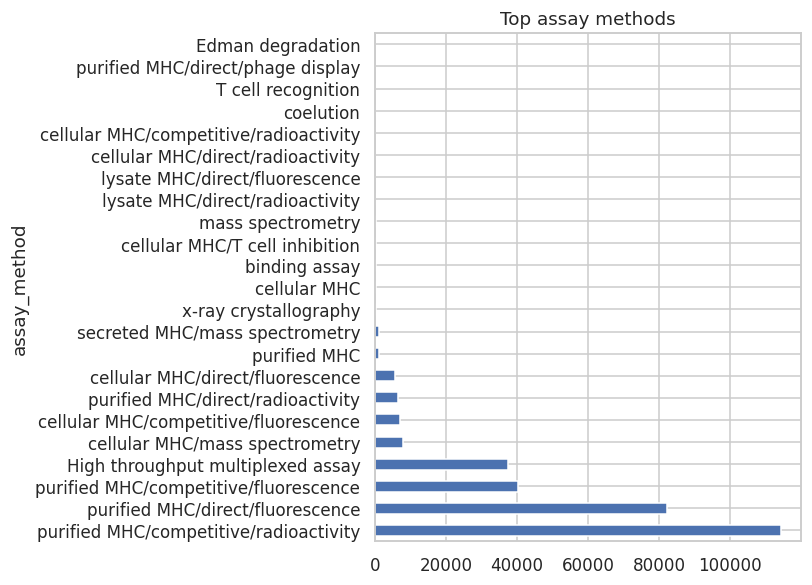

In [13]:
df['assay_method'].value_counts().sort_values(ascending=False).head(30).plot.barh(figsize=(5, 6), title="Top assay methods")

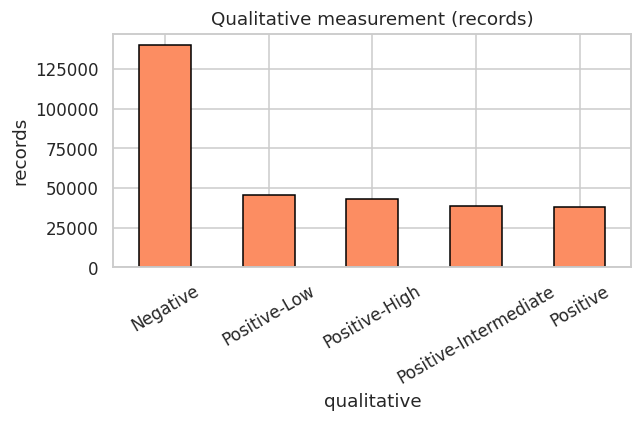

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
df["qualitative"].fillna("(blank)").value_counts().head(8).plot.bar(ax=ax, color="#fc8d62", edgecolor="black", linewidth=1)
ax.set(title="Qualitative measurement (records)", ylabel="records")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

<Axes: title={'center': 'Top assay methods for positive interactions'}, ylabel='assay_method'>

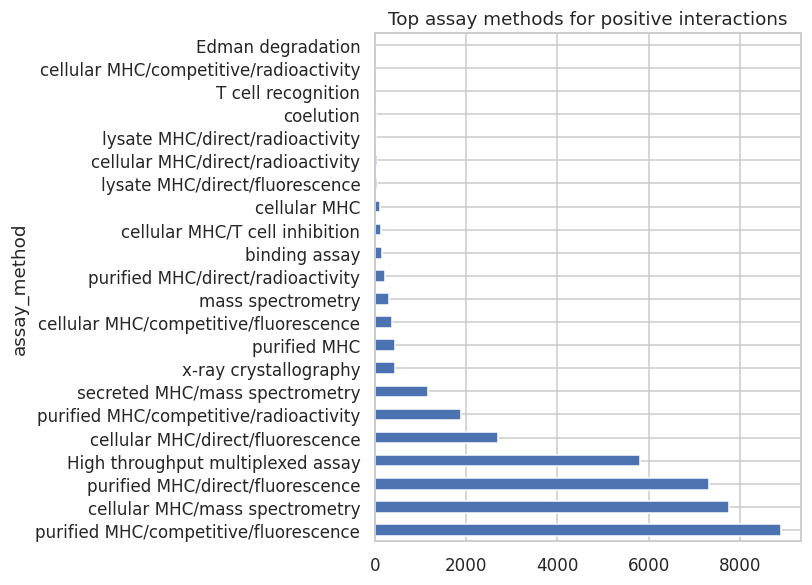

In [15]:
df_pos = df[df["qualitative"] == "Positive"]
df_pos['assay_method'].value_counts().sort_values(ascending=False).head(30).plot.barh(figsize=(5, 6), title="Top assay methods for positive interactions")


In [16]:
# Derived columns
df["length"] = df["peptide"].str.len()
df["is_modified"] = df["modifications"].notna()
df["assay_category"] = np.where(
    df["assay_method"].fillna("").str.contains("mass spectrometry", case=False),
    "eluted (MS)", "binding/other")
# qualitative -> simple positive/negative
df["is_positive"] = df["qualitative"].fillna("").str.startswith("Positive")
df.head(3)

,epitope_iri,peptide,modifications,source_molecule,source_molecule_iri,source_organism,source_organism_iri,species,species_iri,assay_method,qualitative,allele,hla_evidence,mhc_class,length,is_modified,assay_category,is_positive
0,http://www.iedb.org/epitope/31803,KLEDLERDL,NaN,large delta antigen,http://www.ncbi.nlm.nih.gov/protein/AAG26087.1,Hepatitis delta virus TW2667,https://ontology.iedb.org/ontology/ONTIE_0000432,Hepatitis delta virus,http://purl.obolibrary.org/obo/NCBITaxon_12475,cellular MHC/direct/fluorescence,Positive-Low,HLA-A*02:01,NaN,I,9,False,binding/other,True
1,http://www.iedb.org/epitope/36724,LITGRLQSL,NaN,Spike glycoprotein,https://www.uniprot.org/uniprot/P59594.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,cellular MHC/direct/fluorescence,Positive-High,HLA-A2,NaN,I,9,False,binding/other,True
2,http://www.iedb.org/epitope/14829,EVMPVSMAK,NaN,Spike glycoprotein,https://www.uniprot.org/uniprot/P59594.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,purified MHC/direct/fluorescence,Positive-Intermediate,HLA-A*03:01,NaN,I,9,False,binding/other,True


## 2. Headline counts

In [17]:
print("records:           ", f"{len(df):,}")
print("unique peptides:    ", f"{df['peptide'].nunique():,}")
print("unique epitope IRIs:", f"{df['epitope_iri'].nunique():,}")
print("distinct species:   ", f"{df['species'].nunique():,}")
print("distinct alleles:   ", f"{df['allele'].nunique():,}")
print("\nrecords by MHC class:")
print(df["mhc_class"].value_counts())
print("\nunique peptides by MHC class:")
print(df.groupby("mhc_class")["peptide"].nunique())

records:            305,861
unique peptides:     61,618
unique epitope IRIs: 61,618
distinct species:    558
distinct alleles:    354

records by MHC class:
mhc_class
I                169501
II               135557
non classical       803
Name: count, dtype: int64

unique peptides by MHC class:
mhc_class
I                35081
II               26364
non classical      468
Name: peptide, dtype: int64


#### 3. Data-definition breakdowns (decide eluted-vs-binding & positive-vs-negative)

These are **record-level** counts (each assay record counted once) — intentional, since these drive which *records* to keep. Titles say "(records)". Section 5/6 rankings below use **unique peptides**.

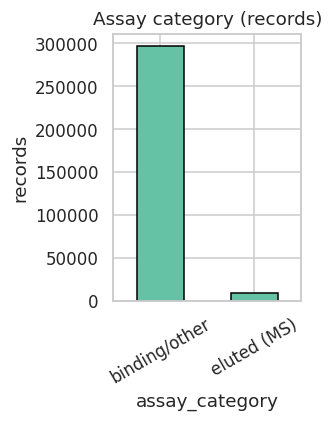

In [18]:
fig, ax = plt.subplots(figsize=(3, 4))
df["assay_category"].value_counts().plot.bar(ax=ax, color="#66c2a5", edgecolor="black", linewidth=1)
ax.set(title="Assay category (records)", ylabel="records")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); 
plt.show()

/tmp/ipykernel_2501805/1187504998.py:4: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


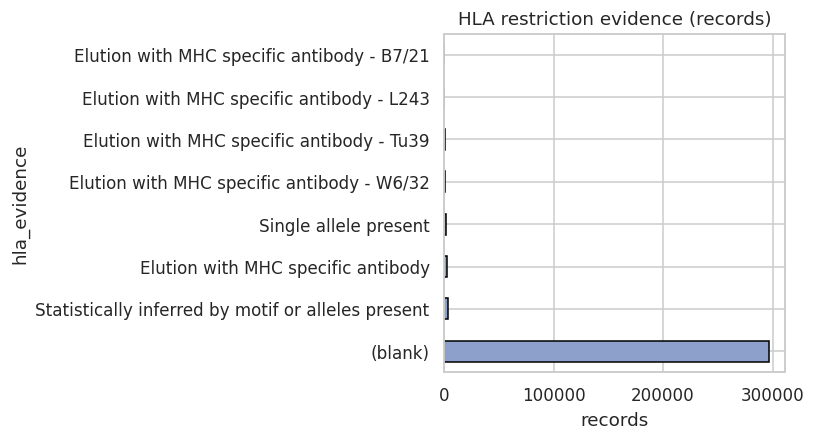

In [19]:
fig, ax = plt.subplots(figsize=(4, 4))
df["hla_evidence"].fillna("(blank)").value_counts().head(8).plot.barh(ax=ax, color="#8da0cb", edgecolor="black", linewidth=1)
ax.set(title="HLA restriction evidence (records)", xlabel="records")
plt.tight_layout(); plt.show()

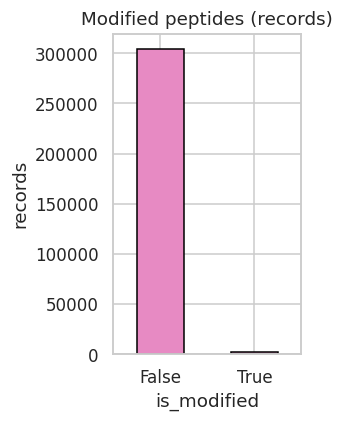

In [20]:
fig, ax = plt.subplots(figsize=(3, 4))
df["is_modified"].value_counts().plot.bar(ax=ax, color="#e78ac3", edgecolor="black", linewidth=1)
ax.set(title="Modified peptides (records)", xlabel="is_modified", ylabel="records")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

In [21]:
print("class x assay_category (records):")
print(pd.crosstab(df["mhc_class"], df["assay_category"]))
print("\npositive vs negative (records):")
print(df["is_positive"].value_counts())

class x assay_category (records):
assay_category  binding/other  eluted (MS)
mhc_class                                 
I                      165232         4269
II                     130519         5038
non classical             749           54

positive vs negative (records):
is_positive
True     165653
False    140208
Name: count, dtype: int64


In [27]:
df_pos = df[df["is_positive"]]
nuiq_pep_pos = df_pos.groupby("mhc_class")["peptide"].nunique().sort_values(ascending=False)

print("Unique epitope (peptide) sequences per MHC class:")
print(nuiq_pep_pos.to_string())


Unique epitope (peptide) sequences per MHC class:
mhc_class
I                29896
II               19936
non classical      307


/tmp/ipykernel_2501805/1059667694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=focus.index, y=focus.values, ax=ax, palette="Set2",


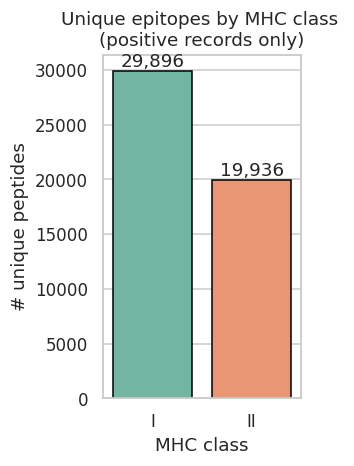

In [34]:

focus = nuiq_pep_pos[nuiq_pep_pos.index.isin(["I", "II"])]
fig, ax = plt.subplots(figsize=(3, 4.4))
sns.barplot(x=focus.index, y=focus.values, ax=ax, palette="Set2", 
            edgecolor="black", linewidth=1)
for i, v in enumerate(focus.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set(title="Unique epitopes by MHC class \n(positive records only)", xlabel="MHC class", ylabel="# unique peptides")
plt.tight_layout(); plt.show()

MHC class I: 492 distinct source species; top 5:
species
Orthopoxvirus vaccinia        7189
Dengue virus                  4861
SARS-CoV1                     1645
Hepacivirus hominis           1616
Mycobacterium tuberculosis    1587 

MHC class II: 178 distinct source species; top 5:
species
Severe acute respiratory syndrome coronavirus 2    11081
SARS-CoV1                                           1185
Influenza A virus                                   1134
Dengue virus                                        1044
Mammarenavirus choriomeningitidis                    981 



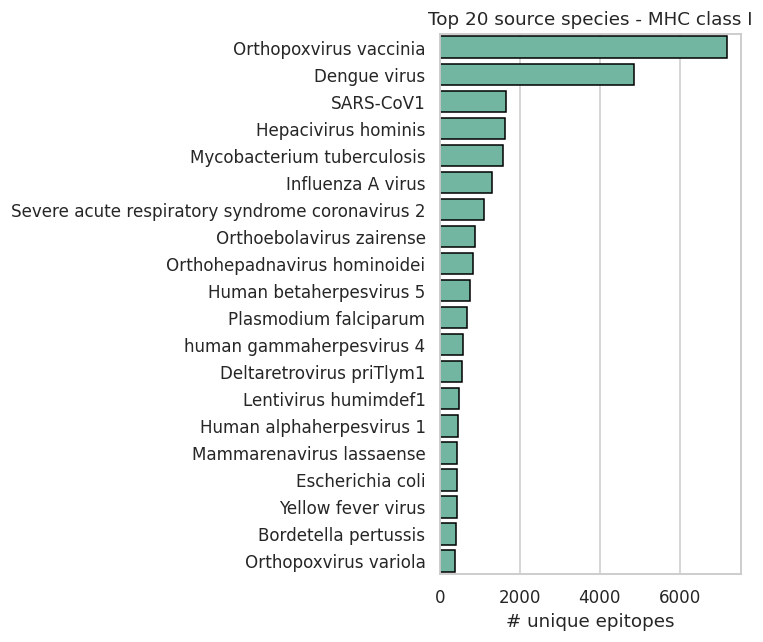

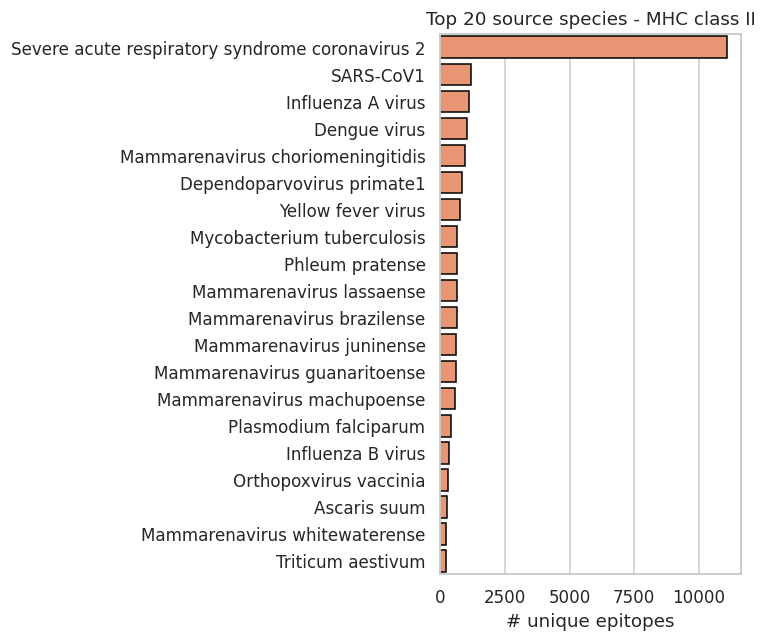

In [ ]:
TOP = 20

def top_species(cls):
    s = (df[df["mhc_class"] == cls]
         .groupby("species")["peptide"].nunique()
         .sort_values(ascending=False))
    return s

for cls in ["I", "II"]:
    s = top_species(cls)
    print(f"MHC class {cls}: {len(s):,} distinct source species; top 5:")
    print(s.head(5).to_string(), "\n")

# Plot 1 — MHC Class I
fig1, ax1 = plt.subplots(figsize=(7, 6))
s1 = top_species("I").head(TOP)
sns.barplot(x=s1.values, y=s1.index, ax=ax1, color="#66c2a5",
             edgecolor="black", linewidth=1)
ax1.set(title=f"Top {TOP} source species - MHC class I",
        xlabel="# unique epitopes", ylabel="")
plt.tight_layout()
plt.show()

# Plot 2 — MHC Class II
fig2, ax2 = plt.subplots(figsize=(7, 6))
s2 = top_species("II").head(TOP)
sns.barplot(x=s2.values, y=s2.index, ax=ax2, color="#fc8d62",
             edgecolor="black", linewidth=1)
ax2.set(title=f"Top {TOP} source species - MHC class II",
        xlabel="# unique epitopes", ylabel="")
plt.tight_layout()
plt.show()

## 4. Peptide length distribution

On **unique peptides** (deduped within class) — so heavily-tested peptides (e.g. popular alleles) don't dominate the shape. This is the right view for the downstream similarity work.

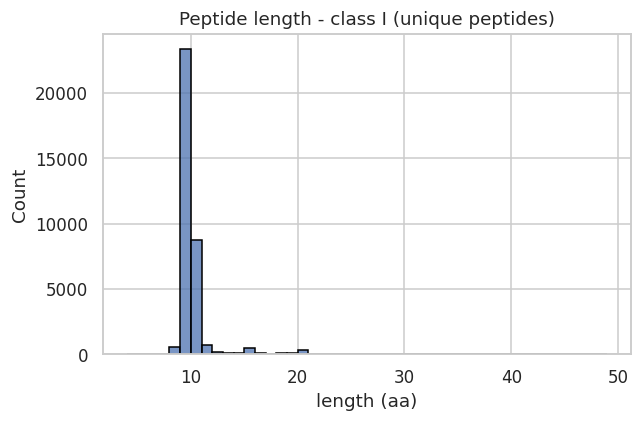

In [66]:
# Length distribution on UNIQUE peptides (dedupe within class) so frequently-tested
# peptides don't dominate the shape.
fig, ax = plt.subplots(figsize=(6, 4))
s = df[df["mhc_class"] == "I"].drop_duplicates("peptide")["length"]
#s = s[(s >= 7) & (s <= 30)]
sns.histplot(s, binwidth=1, ax=ax, edgecolor="black", linewidth=1)
ax.set(title="Peptide length - class I (unique peptides)", xlabel="length (aa)")
plt.tight_layout(); 
plt.show()

In [74]:
s.describe()
s.value_counts().sort_index().head(10)

length
4         1
5         4
6        10
7        47
8       538
9     23369
10     8759
11      733
12      169
13       95
Name: count, dtype: int64

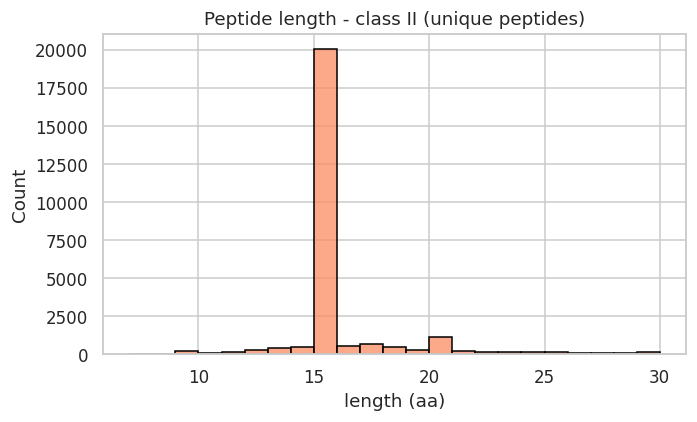

                 count       mean       std  min   25%   50%   75%   max
mhc_class                                                               
I              35081.0   9.651749  1.978075  4.0   9.0   9.0  10.0  49.0
II             26364.0  15.800789  3.122028  5.0  15.0  15.0  15.0  80.0
non classical    468.0   9.254274  1.362343  8.0   9.0   9.0   9.0  23.0


In [63]:
fig, ax = plt.subplots(figsize=(6.5, 4))
s = df[df["mhc_class"] == "II"].drop_duplicates("peptide")["length"]
s = s[(s >= 7) & (s <= 30)]
sns.histplot(s, binwidth=1, ax=ax, color="#fc8d62", edgecolor="black", linewidth=1)
ax.set(title="Peptide length - class II (unique peptides)", xlabel="length (aa)")
plt.tight_layout(); plt.show()

# length stats on unique peptides per class
print(df.drop_duplicates(["mhc_class", "peptide"]).groupby("mhc_class")["length"].describe())

## 5. Pathogen (species) and source-molecule coverage

In [67]:
for cls in ["I", "II"]:
    sub = df[df["mhc_class"] == cls]
    top = sub.groupby("species")["peptide"].nunique().sort_values(ascending=False).head(20)
    print(f"\n=== MHC class {cls}: {sub['species'].nunique()} species, top 20 by unique peptides ===")
    print(top.to_string())


=== MHC class I: 492 species, top 20 by unique peptides ===
species
Orthopoxvirus vaccinia                             7189
Dengue virus                                       4861
SARS-CoV1                                          1645
Hepacivirus hominis                                1616
Mycobacterium tuberculosis                         1587
Influenza A virus                                  1305
Severe acute respiratory syndrome coronavirus 2    1113
Orthoebolavirus zairense                            877
Orthohepadnavirus hominoidei                        814
Human betaherpesvirus 5                             753
Plasmodium falciparum                               688
human gammaherpesvirus 4                            568
Deltaretrovirus priTlym1                            544
Lentivirus humimdef1                                469
Human alphaherpesvirus 1                            460
Mammarenavirus lassaense                            420
Escherichia coli                   

In [68]:
# How concentrated are epitopes within a pathogen across its source proteins?
prot = (df[df["mhc_class"] == "I"]
        .groupby(["species", "source_molecule"])["peptide"].nunique()
        .sort_values(ascending=False).head(20))
print("Top source proteins by unique class I peptides:")
print(prot.to_string())

Top source proteins by unique class I peptides:
species                                          source_molecule                              
Dengue virus                                     Genome polyprotein                               4819
SARS-CoV1                                        Replicase polyprotein 1ab                        1000
Hepacivirus hominis                              Genome polyprotein                                754
                                                 polyprotein                                       518
Orthoebolavirus zairense                         nucleoprotein NP                                  402
                                                 glycoprotein                                      367
Yellow fever virus                               polyprotein                                       366
Mycobacterium tuberculosis                       hypothetical protein                              348
Deltaretrovirus priTlym1         

## 6. HLA allele coverage & resolution

In [69]:
cls1 = df[df["mhc_class"] == "I"]
# allele resolution: count fields after the locus (HLA-A*02:01 -> 2 fields)
def resolution(a):
    if not isinstance(a, str) or "*" not in a:
        return "low/serotype"
    return f"{a.split('*')[1].count(':') + 1}-field"
print("class I allele resolution (records):")
print(cls1["allele"].map(resolution).value_counts())
print("\ntop 20 class I alleles by unique peptides:")
print(cls1.groupby("allele")["peptide"].nunique().sort_values(ascending=False).head(20).to_string())

class I allele resolution (records):
allele
2-field         166943
low/serotype      2556
3-field              2
Name: count, dtype: int64

top 20 class I alleles by unique peptides:
allele
HLA-A*02:01    14684
HLA-A*03:01     6989
HLA-A*11:01     6526
HLA-A*31:01     4782
HLA-B*07:02     4759
HLA-B*15:01     4531
HLA-A*01:01     4355
HLA-A*24:02     3974
HLA-A*68:02     3937
HLA-A*02:03     3834
HLA-A*68:01     3293
HLA-A*02:06     3274
HLA-A*26:01     3260
HLA-B*58:01     3141
HLA-B*40:01     2939
HLA-A*33:01     2756
HLA-B*35:01     2680
HLA-A*02:02     2623
HLA-B*08:01     2519
HLA-A*69:01     2390


## 7. Save working table

Saved as CSV for the similarity notebook.

In [ ]:
OUT = "iedb_human_pathogen_working_table_v2.csv"
df.to_csv(OUT, index=False)
print(f"saved {len(df):,} rows -> {OUT}")
# df.to_parquet('iedb_human_pathogen_working_table.parquet', index=False)

saved 305,861 rows -> iedb_human_pathogen_working_table.csv


In [72]:
print(df.shape)
print(df.head(4))

(305861, 18)
                         epitope_iri    peptide modifications  \
0  http://www.iedb.org/epitope/31803  KLEDLERDL           NaN   
1  http://www.iedb.org/epitope/36724  LITGRLQSL           NaN   
2  http://www.iedb.org/epitope/14829  EVMPVSMAK           NaN   
3  http://www.iedb.org/epitope/14829  EVMPVSMAK           NaN   

       source_molecule                             source_molecule_iri  \
0  large delta antigen  http://www.ncbi.nlm.nih.gov/protein/AAG26087.1   
1   Spike glycoprotein        https://www.uniprot.org/uniprot/P59594.1   
2   Spike glycoprotein        https://www.uniprot.org/uniprot/P59594.1   
3   Spike glycoprotein        https://www.uniprot.org/uniprot/P59594.1   

                source_organism  \
0  Hepatitis delta virus TW2667   
1                     SARS-CoV1   
2                     SARS-CoV1   
3                     SARS-CoV1   

                                source_organism_iri                species  \
0  https://ontology.iedb.org/ontolog